In [14]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 폰트
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 깨짐 방지

In [15]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Admin\Desktop\hhh\Horse\data_preprocessing\merged_data_kr_Nan.csv", encoding="utf-8-sig")

In [16]:
df["그룹"] = df["경주일자"].astype(str) + "_" + df["경주번호"].astype(str)

In [17]:
df.head()

,분할경주여부,마명,마번,기수번호,조교사번호,부담구분,출전번호,경주일자,경주등급,출전마구분,...,마체중,출생일,성별,소유자명,생산국,부마명,소재지,출주두수_대비_상대순위점수,평균_시속,그룹
0,0,파이널축제,45339,080342,70170.0,2,3,2023-01-07,일반,Rookie2,...,490.0,2020-03-10,수,럭키,한국,지롤라모,서울경마공원,0.636364,56.047904,2023-01-07_1
1,0,아르고리치,45921,080366,70146.0,2,6,2023-01-07,일반,Rookie2,...,496.0,2020-04-08,수,우태율,한국,컬러즈플라잉,서울경마공원,0.909091,56.453559,2023-01-07_1
2,0,파워에치드,45734,080339,70166.0,2,11,2023-01-07,일반,Rookie2,...,483.0,2020-03-18,거,박정재,한국,에치드,서울경마공원,0.363636,55.714286,2023-01-07_1
3,0,베스트선,45369,080405,70115.0,3,1,2023-01-07,일반,일반,...,479.0,2020-02-28,거,베스트샤인조합,한국,테이크차지인디,서울경마공원,0.818182,56.521739,2023-01-07_7
4,0,슈어윈,45240,080103,70096.0,3,7,2023-01-07,일반,일반,...,413.0,2020-02-13,암,지성배,한국,BERNARDINI,서울경마공원,1.000000,57.352941,2023-01-07_7


In [18]:
df.columns

Index(['분할경주여부', '마명', '마번', '기수번호', '조교사번호', '부담구분', '출전번호', '경주일자', '경주등급',
       '출전마구분', '경주번호', '야간경마여부', '마필등급', '출주두수', '경주로상태', '날씨', '마체중', '출생일',
       '성별', '소유자명', '생산국', '부마명', '소재지', '출주두수_대비_상대순위점수', '평균_시속', '그룹'],
      dtype='str')

In [19]:
df.dtypes.to_frame("dtype")

,dtype
분할경주여부,int64
마명,str
마번,int64
기수번호,str
조교사번호,float64
부담구분,int64
출전번호,int64
경주일자,str
경주등급,str
출전마구분,str


# 

초기 shape: (15460, 26)
중복 컬럼 제거 후: (15460, 26)
완전 동일 컬럼 제거: []


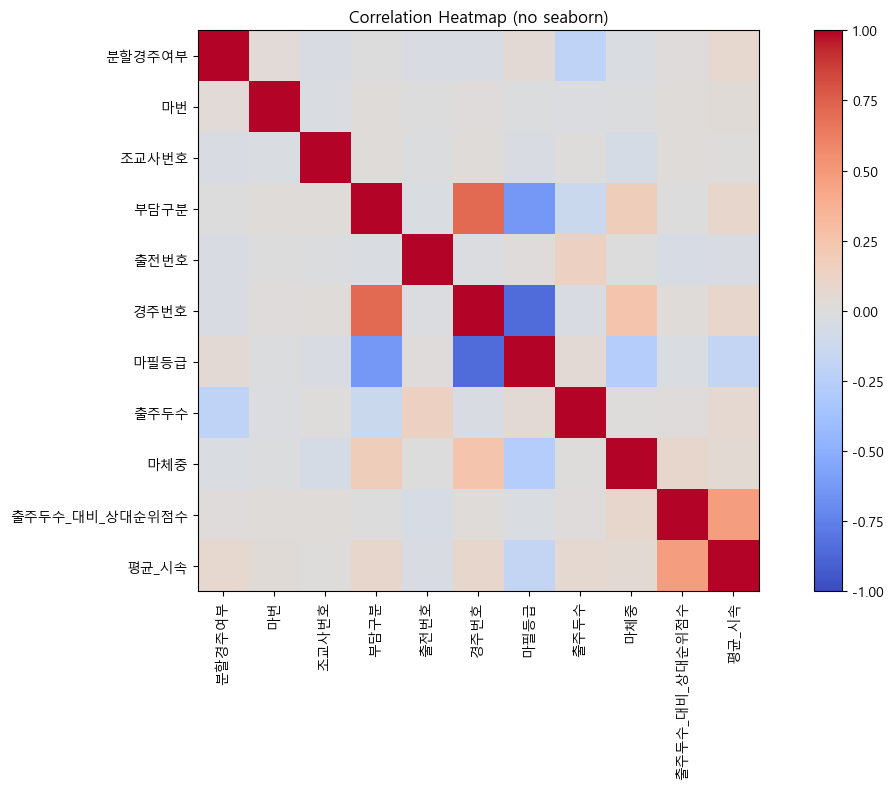

상관 기반 제거 컬럼: []
최종 shape: (15460, 26)

===== 분할경주여부 =====


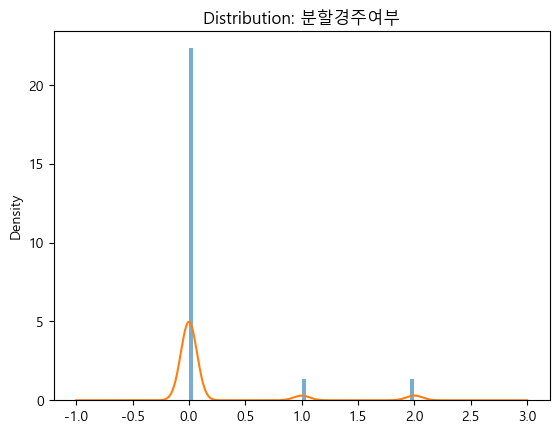

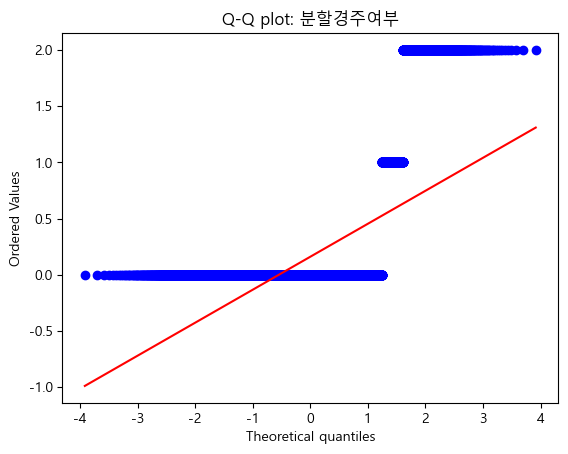

p-value: 1.370121252079666e-73
→ 정규분포 아님

===== 마번 =====


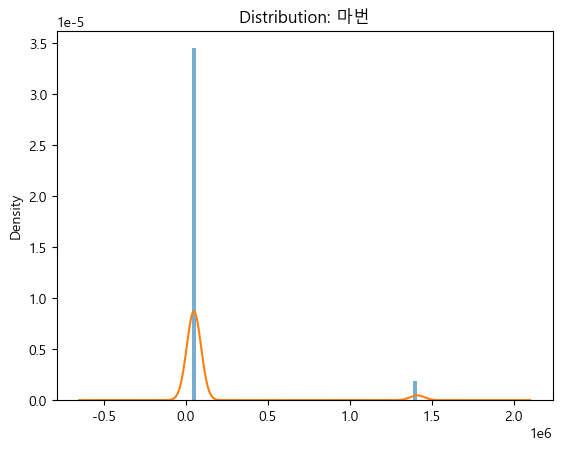

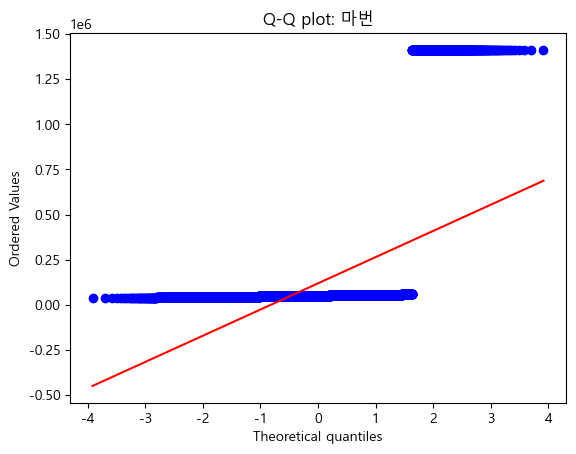

p-value: 1.7859385873240272e-76
→ 정규분포 아님

===== 조교사번호 =====


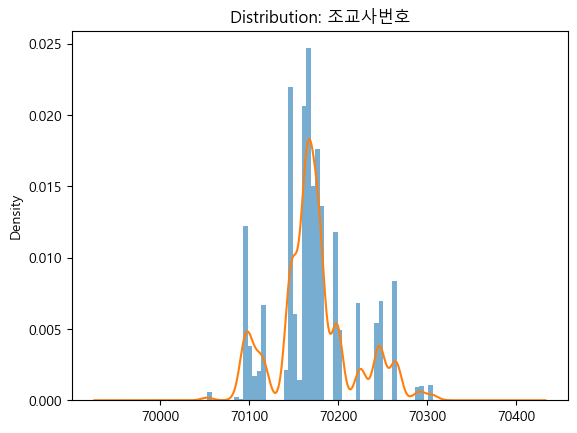

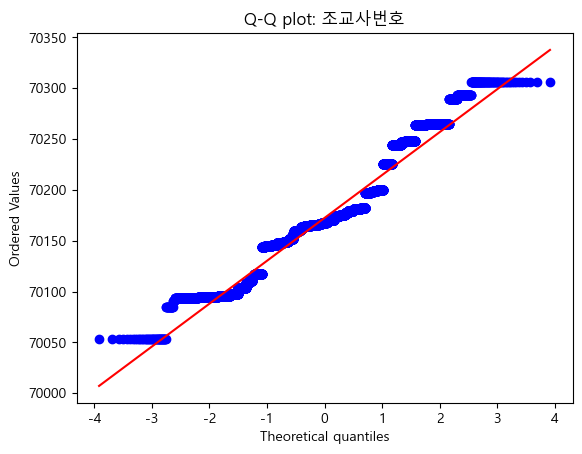

p-value: 6.535507628572466e-34
→ 정규분포 아님

===== 부담구분 =====


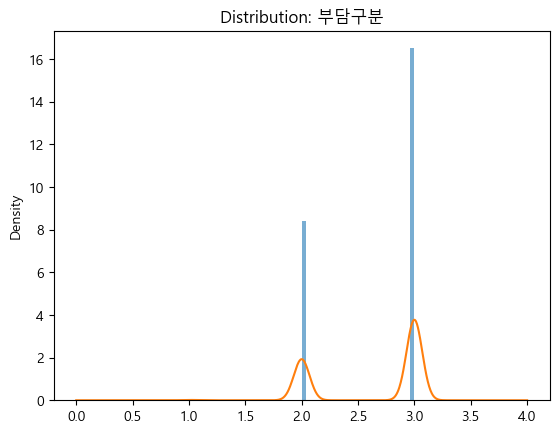

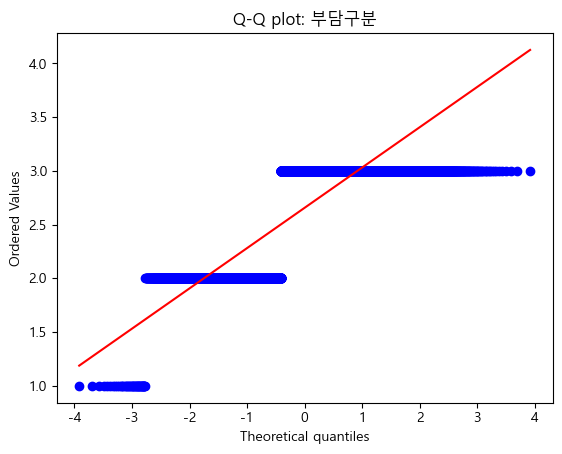

p-value: 3.3348911915456947e-63
→ 정규분포 아님

===== 출전번호 =====


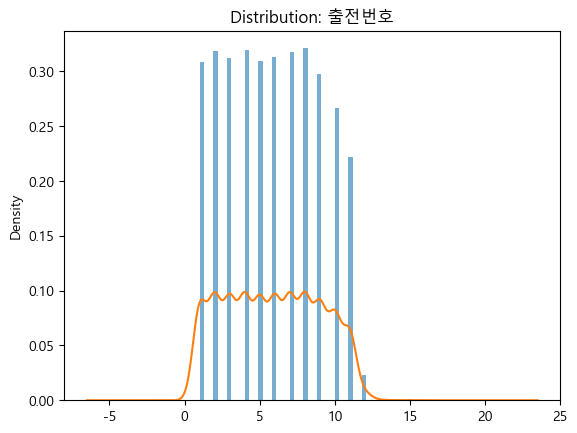

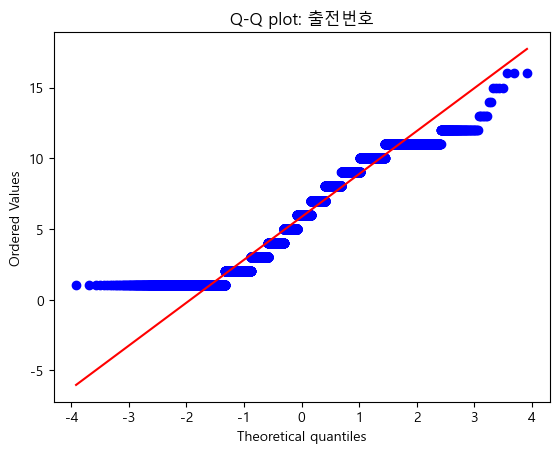

p-value: 1.8120940895385475e-30
→ 정규분포 아님

===== 경주번호 =====


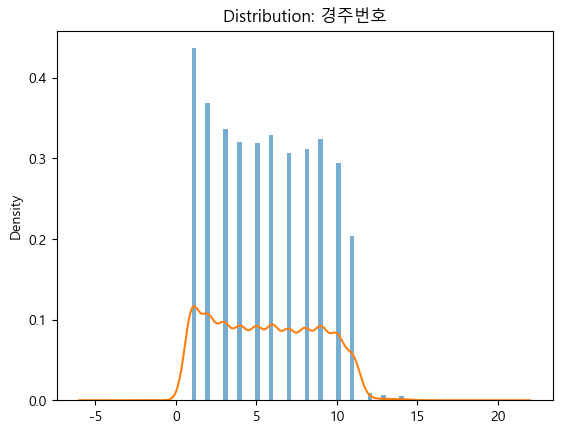

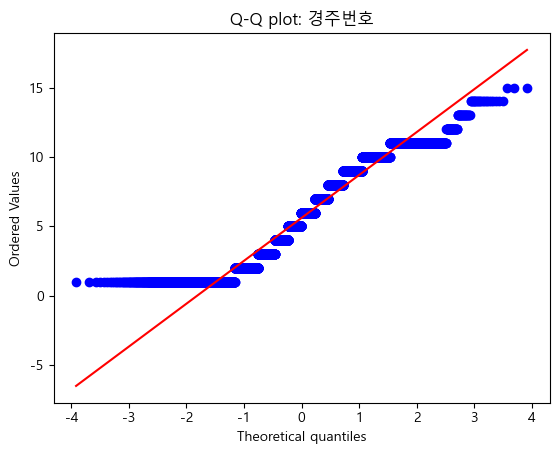

p-value: 8.040493808475164e-33
→ 정규분포 아님

===== 마필등급 =====


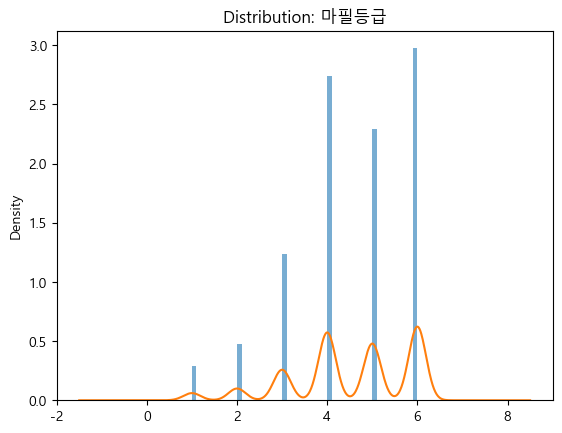

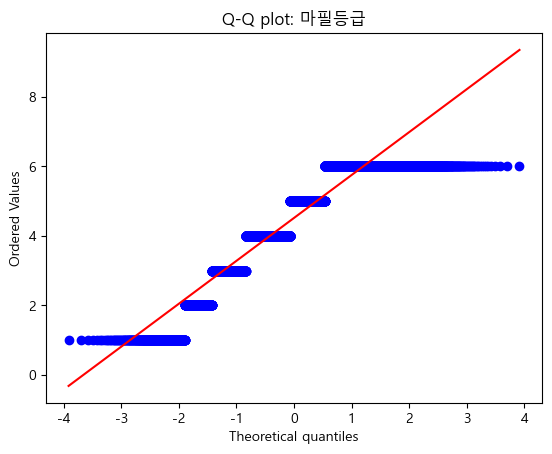

p-value: 4.437459988044918e-43
→ 정규분포 아님

===== 출주두수 =====


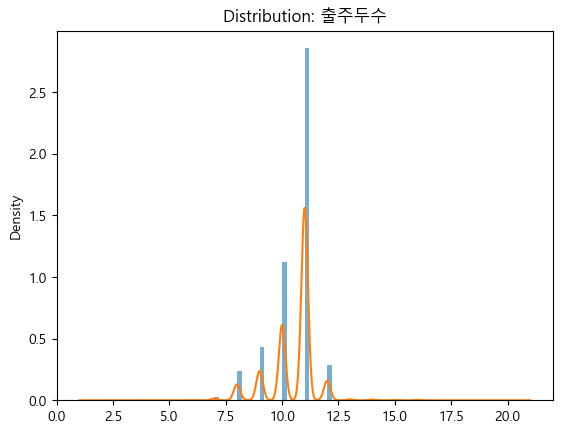

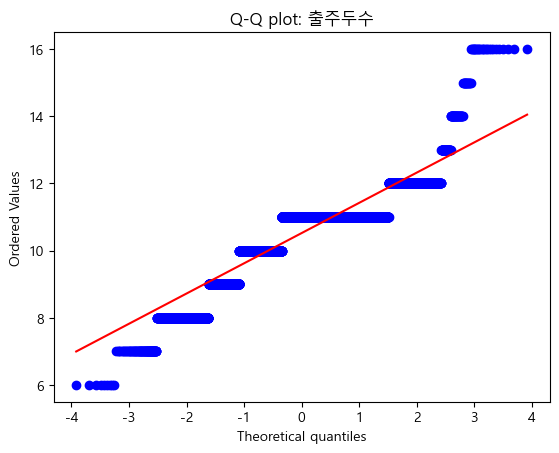

p-value: 4.755539841389577e-50
→ 정규분포 아님

===== 마체중 =====


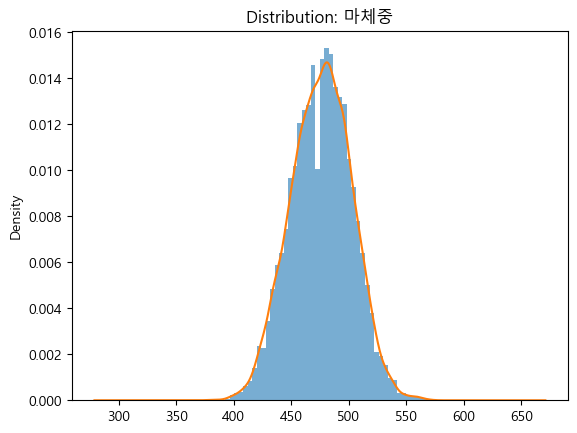

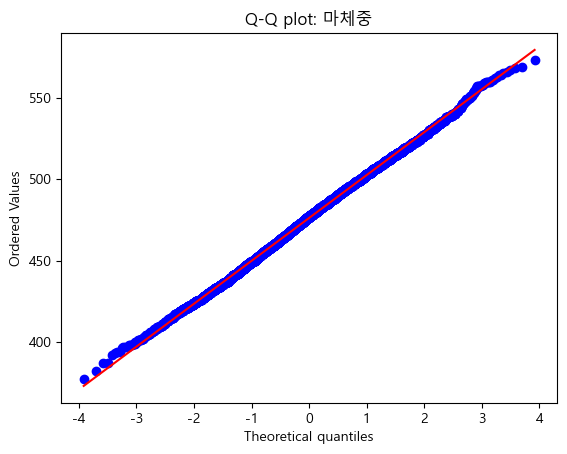

p-value: 0.0019198969172022576
→ 정규분포 아님

===== 출주두수_대비_상대순위점수 =====


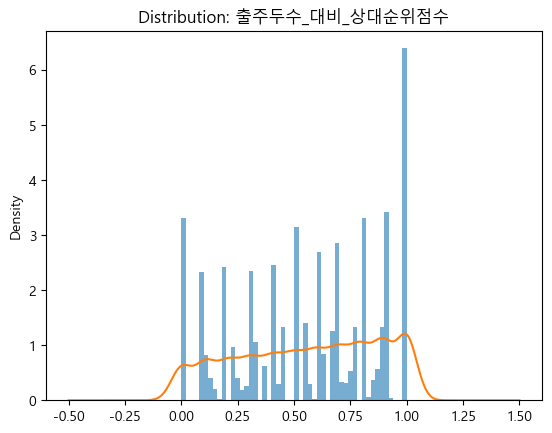

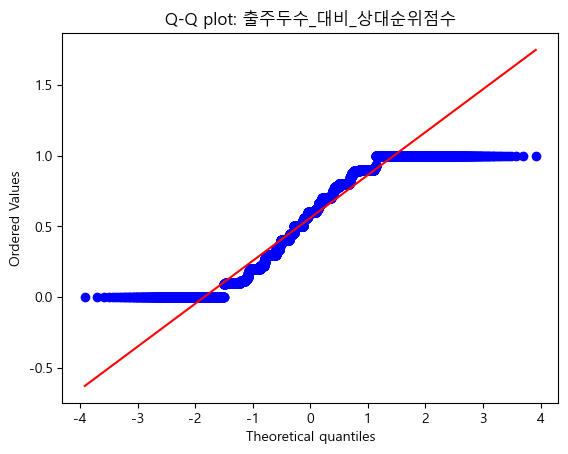

p-value: 9.403482642182947e-34
→ 정규분포 아님

===== 평균_시속 =====


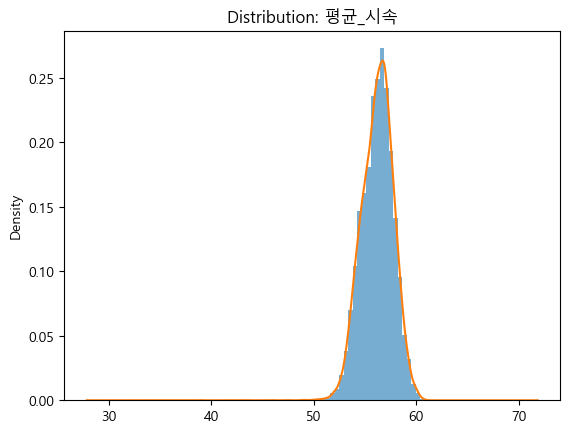

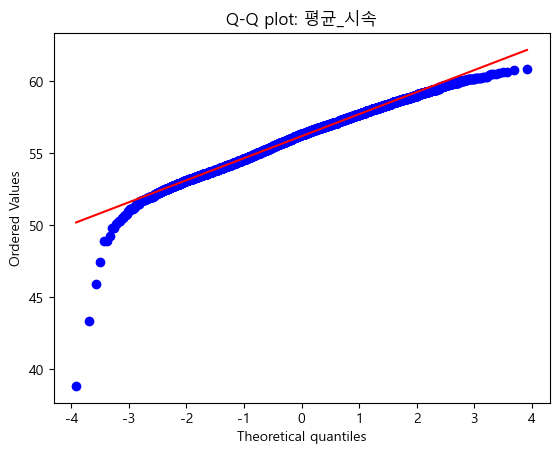

p-value: 2.077247813653381e-14
→ 정규분포 아님
전처리 완료


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# =========================
# 0. 데이터 로드
# =========================

print("초기 shape:", df.shape)


# =========================
# 1. 완전 중복 컬럼 제거
# =========================
df = df.loc[:, ~df.T.duplicated()]
print("중복 컬럼 제거 후:", df.shape)


# =========================
# 2. 완전 동일 값 컬럼 제거
# =========================
duplicate_cols = []

cols = df.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if df[cols[i]].equals(df[cols[j]]):
            duplicate_cols.append(cols[j])

df = df.drop(columns=set(duplicate_cols))
print("완전 동일 컬럼 제거:", duplicate_cols)


# =========================
# 3. 숫자형 컬럼
# =========================
num_df = df.select_dtypes(include=["int64", "float64"])


# =========================
# 4. 상관도 (matplotlib 버전)
# =========================
corr = num_df.corr()

plt.figure(figsize=(12, 8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap (no seaborn)")
plt.tight_layout()
plt.show()


# =========================
# 5. 상관 기반 feature 제거
# =========================
threshold = 0.9

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

df = df.drop(columns=to_drop)

print("상관 기반 제거 컬럼:", to_drop)
print("최종 shape:", df.shape)


# =========================
# 6. 정규성 체크 함수 (matplotlib only)
# =========================
def check_normality(data, col, sample_size=3000):
    print(f"\n===== {col} =====")

    values = data[col].dropna()

    # 히스토그램 (seaborn 대신 matplotlib)
    plt.figure()
    plt.hist(values, bins=50, density=True, alpha=0.6)

    # KDE (간단 근사)
    values.plot(kind="kde")

    plt.title(f"Distribution: {col}")
    plt.show()

    # Q-Q plot
    plt.figure()
    stats.probplot(values, dist="norm", plot=plt)
    plt.title(f"Q-Q plot: {col}")
    plt.show()

    # Shapiro test
    sample = values
    if len(sample) > sample_size:
        sample = sample.sample(sample_size)

    stat, p = stats.shapiro(sample)

    print("p-value:", p)

    if p > 0.05:
        print("→ 정규분포 가능성 있음")
    else:
        print("→ 정규분포 아님")


# =========================
# 7. numeric 전체 검사
# =========================
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    check_normality(df, col)



print("전처리 완료")

In [21]:


df.columns


Index(['분할경주여부', '마명', '마번', '기수번호', '조교사번호', '부담구분', '출전번호', '경주일자', '경주등급',
       '출전마구분', '경주번호', '야간경마여부', '마필등급', '출주두수', '경주로상태', '날씨', '마체중', '출생일',
       '성별', '소유자명', '생산국', '부마명', '소재지', '출주두수_대비_상대순위점수', '평균_시속', '그룹'],
      dtype='str')

===== Target Correlation =====
출주두수_대비_상대순위점수    1.000000
평균_시속             0.469467
마체중               0.088500
마번                0.020360
조교사번호             0.018472
경주번호              0.016709
분할경주여부            0.012182
출주두수              0.010865
부담구분             -0.004471
마필등급             -0.025462
출전번호             -0.048747
Name: 출주두수_대비_상대순위점수, dtype: float64


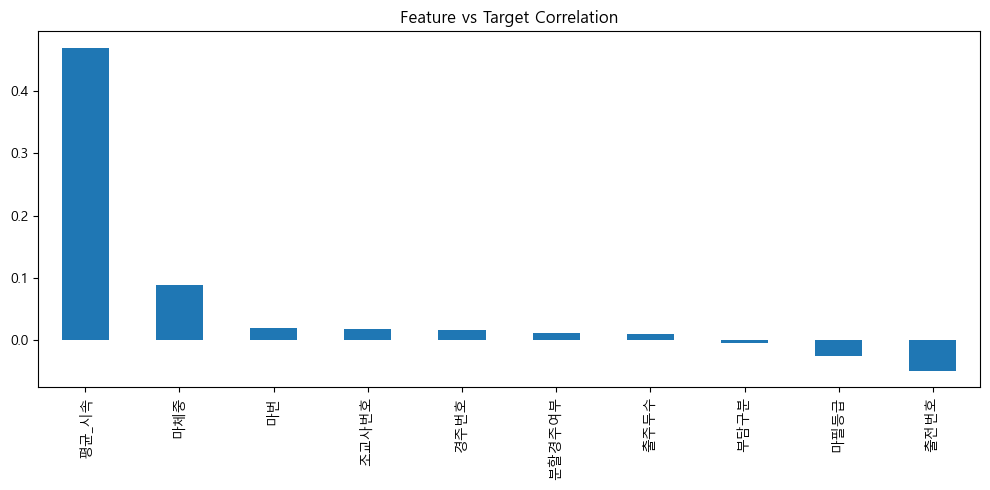

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

target = "출주두수_대비_상대순위점수"

# 숫자형만
num_df = df.select_dtypes(include=["int64", "float64"])

# 상관계수
corr = num_df.corr()

# 타겟과 상관
target_corr = corr[target].sort_values(ascending=False)

print("===== Target Correlation =====")
print(target_corr)

# 시각화
plt.figure(figsize=(10,5))
target_corr.drop(target).plot(kind="bar")
plt.title("Feature vs Target Correlation")
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_20260\2173346792.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns.tolist()


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001956 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3456
[LightGBM] [Info] Number of data points in the train set: 15460, number of used features: 24
[LightGBM] [Info] Start training from score 0.559377
===== Feature Importance =====
   feature  importance
3     기수번호        3446
23   평균_시속        3053
7     경주일자        2787
19    소유자명        1170
21     부마명        1149
1       마명        1132
10    경주번호         995
17     출생일         987
12    마필등급         837
2       마번         718
16     마체중         625
6     출전번호         560
13    출주두수         379
4    조교사번호         360
5     부담구분         173
18      성별         143
14   

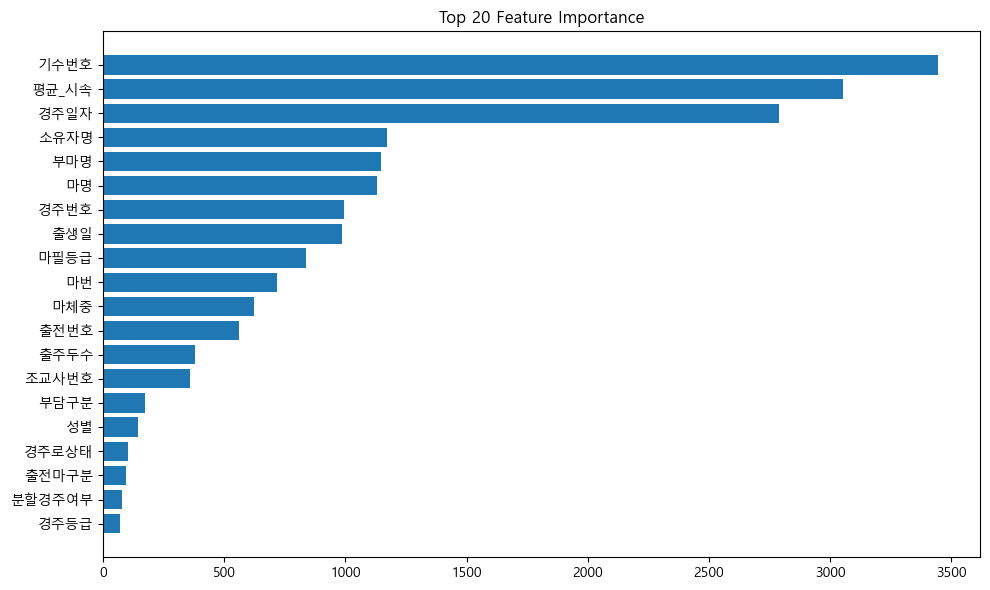

In [24]:
import lightgbm as lgb

target = "출주두수_대비_상대순위점수"

X = df.drop(columns=[target, "그룹"])
y = df[target]

# categorical 처리
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

for c in cat_cols:
    X[c] = X[c].astype("category")

# train
train_data = lgb.Dataset(X, label=y, categorical_feature=cat_cols)

params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 64,
    "seed": 42
}

model = lgb.train(params, train_data, num_boost_round=300)

# importance
fi = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importance()
}).sort_values("importance", ascending=False)

print("===== Feature Importance =====")
print(fi)

# 시각화
import matplotlib.pyplot as plt

top = fi.head(20)

plt.figure(figsize=(10,6))
plt.barh(top["feature"][::-1], top["importance"][::-1])
plt.title("Top 20 Feature Importance")
plt.tight_layout()
plt.show()